<img src="资源 12@10x.png" alt="图片描述" style="width: 50%;" />
<img src="数据集.png" alt="图片描述" style="width: 80%;" />
<img src="几何原型.png" alt="图片描述" style="width: 40%;" />
<img src="网络结构.png" alt="图片描述" style="width: 40%;" />

In [ ]:
import datetime
import time
from Parameters import *
mix_ratio = 1
surf_npoint_source = 8192
target_npoint = 2048
args = parser.parse_known_args()[0]
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_index
sys.path.insert(1, os.path.dirname(os.path.abspath(__name__)))
import logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
import torch
from modelPAR_volumeAL import PointAR
from dataset.FFDshape_volume import FFDshape_ptp_ss
from Loss import LabelSmoothingCE, reg_loss
from Transforms3 import PCDPretreatment, get_data_augment
from Trainer_volume_post import Trainer
from utils import IdentityScheduler

post_dir = r'.'
stl_base =  'ShapeSource'
shape_dict = {'cap': 'capsule', 'sld': 'slender', 'spl': 'spaceplane', 'x33':'X-33', 'wr': 'waverider','ss':'spaceshuttle135k'}
shape_name = 'ss' # cap, sld, spl, x33, wr, rocket

pth_file = r'result_train\PAR_h8_model=basic_c_ds=SS2000_aug=basic_lr=0.001_wd=1e-08_bs=16_Adam_cosine\PAR_h8_SS2000_epoch300.pth'
cmd = f'python main_PAR_vol_al.py --name PAR_h8 -bs 16 --lr 3e-4 -ec 5 --dataset none -ne 300 --att_cfg 512 256 128 -en 1 -ts 1400 --optimizer Adam --auto_cast False -cp {pth_file}'
cmd_list = cmd.split()
param_list = []
param_translate = {'-bs':'--batch_size', '-ec':'--eval_cycle', '-ne':'--num_epochs',
                    '-en':'--expand_num', '-ts':'--train_sample_idx','-cp':'--checkpoint'}
# 遍历list
for i in range(len(cmd_list)):
    if cmd_list[i].startswith('-') or cmd_list[i].startswith('--'):
        if cmd_list[i].startswith('-') and not cmd_list[i].startswith('--'):
            key = param_translate[cmd_list[i]]
        else:
            key = cmd_list[i]
        j = 1
        param_list.append(key)
        while (i+j)<len(cmd_list) and not cmd_list[i+j].startswith('-'):
            param_list.append(cmd_list[i+j])
            j = j+1

print(param_list)
timestamp = os.path.getmtime(param_list[-1])
dt = datetime.datetime.fromtimestamp(timestamp)
print(f"pth生成时间：{dt.year}-{dt.month:02d}-{dt.day:02d} {dt.hour:02d}:{dt.minute:02d}:{dt.second:02d}")
args = parser.parse_args(param_list)

def eval_init():
    # 解析参数
    if args.use_cuda and torch.cuda.is_available():
        args.device = torch.device('cuda')
        gpus = list(range(torch.cuda.device_count()))
        torch.cuda.set_device('cuda:{}'.format(gpus[0]))
    else:
        args.device = torch.device('cpu')
    
    att_cfg = args.att_cfg
    print(att_cfg)
    model_cfg = MODEL_CONFIG[args.model_cfg]
    max_input = model_cfg['max_input']
    normal = model_cfg['normal']
    
    if args.optimizer.lower() == 'adamw':
        Optimizer = torch.optim.AdamW
    elif args.optimizer == 'Adam':
        Optimizer = torch.optim.Adam
    elif args.optimizer == 'SGD':
        Optimizer = torch.optim.SGD
    
    if args.scheduler.lower() == 'identity':
        Scheduler = IdentityScheduler
    else:
        args.scheduler = 'cosine'
        Scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

    # 数据变换、加载数据集
    logger.info('Prepare Data')
    '''数据变换、加载数据集'''
    data_augment, random_sample, random_drop = get_data_augment(DATA_AUG_CONFIG[args.data_aug])
   
    transforms = PCDPretreatment(surf_npoint_source=surf_npoint_source, target_npoint=target_npoint, down_sample='random', normal=normal,
                                 data_augmentation=data_augment, random_drop=random_drop, resampling=random_sample, mix_ratio=mix_ratio)

    '''Prepare dataset'''
    if args.dataset_path is None or args.dataset_path == 'default':
        if args.dataset == 'WR_fl':
            # default_dataset_path_list = [r'F:\WR_fl']
            default_dataset_path_list = [r'../MHATT_simp4/dataroot']
        elif args.dataset == 'SS2000':
            default_dataset_path_list = [r'D:\database\shapesffd3']
        # else:
        #     raise ValueError
        
        # for path in default_dataset_path_list:
        #     if os.path.exists(path):
        #         args.dataset_path = path
        #         break
        # else:  # this is for-else block, indent is not missing
        #     raise FileNotFoundError(f'Dataset path not found.')
        logger.info(f'Load default dataset from {args.dataset_path}')
    dataset = None
    if args.dataset == 'WR_fl':
        dataset = FFDshape_ptp(dataroot=args.dataset_path, transforms=transforms,
                                npoints_target=target_npoint, eval_npoints=surf_npoint_source, 
                                expand_num=args.expand_num, tsample=args.train_sample_idx)
    elif args.dataset == 'SS2000':
        dataset = FFDshape_ptp_ss(dataroot=args.dataset_path, transforms=transforms,
                                npoints_target=target_npoint, eval_npoints=surf_npoint_source, 
                                expand_num=args.expand_num, tsample=args.train_sample_idx,
                                gettest=args.gettest)

    # 模型与损失函数
    logger.info('Prepare Models...')
    model = PointAR(att_cfg if att_cfg is not None else [512,256]).to(device=args.device)
    # sampler = PointAR([1], sampler=True).to(device=args.device)
    sampler = None
    if args.optimizer == 'SGD':
        optimizer = Optimizer(model.parameters(), lr=args.lr)
    else:
        optimizer = Optimizer(model.parameters(), lr=args.lr, weight_decay=args.wd)
    scheduler = Scheduler(optimizer, T_max=args.num_epochs, eta_min=0)# eta_min=args.lr * 0.001
    if sampler is not None:
        optimizer_s = Optimizer(sampler.parameters(), lr=args.lr, weight_decay=args.wd)
        scheduler_s = Scheduler(optimizer_s, T_max=args.num_epochs, eta_min=0)
    else:
        optimizer_s = None
        scheduler_s = None
    criterion = reg_loss().to(args.device)
    
    


    # 训练器
    logger.info('Trainer launching...')
    trainer = Trainer(
        args=args,
        model=model,
        sampler=None,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        dataset=dataset,
        mode=args.mode,
        optimizer_s=None,
        scheduler_s=None
    )
    # trainer.post()
    # trainer.run()
    # trainer.test()
    return trainer
eval = eval_init()
model = eval.model

import numpy as np
from sklearn import metrics
import trimesh
device = eval.args.device


stl_file = os.path.join(f'{post_dir}\ShapeSource', f'{shape_dict[shape_name]}.stl')
# stl_file = r'E:\WR_fl\pycode\autofluent\shape_set\waverider\shapes_N80_D30_221_seed1_RTY\shape_075.stl'
mesh_data = trimesh.load(stl_file)
points = mesh_data.vertices
faces = mesh_data.faces
normals = mesh_data.face_normals
if shape_name=='ss':
    points = points[:, [0,2,1]]
    normals = normals[:, [0,2,1]]
##! rot
AOA = 0
AOA = np.radians(-AOA)
rotation_matrix = np.array([
    [np.cos(AOA), 0, np.sin(AOA)],
    [0, 1, 0],
    [-np.sin(AOA), 0, np.cos(AOA)]
])

# 对每个点应用旋转矩阵
points = points.dot(rotation_matrix)
normals = normals.dot(rotation_matrix)
##

xyzn_surf = points[faces, :].mean(1)

# normalize
scale = xyzn_surf[:,:3].max(0) - xyzn_surf[:,:3].min(0)
xyzn_surf[:,:3] = xyzn_surf[:,:3] / scale.max()
points[:,:3] = points[:,:3] / scale.max()

# shift
shift = xyzn_surf[:, :3].mean(0)
xyzn_surf[:,:3] = xyzn_surf[:,:3] - shift
points[:,:3] = points[:,:3] - shift
# check normals
normals_cross = (xyzn_surf - xyzn_surf.mean(0)) * normals
normals_cross = sum(normals_cross.sum(-1)>0)/len(normals_cross)
if normals_cross<-0.7:
    normals = -normals
elif normals_cross>0.7:
    normals = normals
else:
    raise ValueError
# normals = -normals
# to tensor
xyzn_surf = torch.from_numpy(np.concatenate((xyzn_surf, normals), axis=1)).unsqueeze(0).permute(0,2,1).float()
xyzn_surf_source = xyzn_surf

In [ ]:
model._att = True
pred = model(xyzn_surf_source.to(device), xyz_volume.to(device)).squeeze(0)
pred.backward()

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import r2_score
from plotly.subplots import make_subplots
colorbar_title = ['<i>C<sub>p</sub></i>', 'Rho', 'Mach']
x_points = torch.linspace(xyzn_surf_source[0, 0, :].min().to('cpu')*2, xyzn_surf_source[0, 0, :].max().to('cpu')*2, 1000)
z_points = torch.linspace(xyzn_surf_source[0, 2, :].min().to('cpu')*3, xyzn_surf_source[0, 2, :].max().to('cpu')*3, 500)
xyz_volume = xyzn_surf_source[0, 1, :].mean().to('cpu')*torch.ones(3,len(x_points)*len(z_points))
# 生成网格

grid_x, grid_z = torch.meshgrid(x_points, z_points)
xyz_volume[0,:] = grid_x.reshape(1,-1)[0]
xyz_volume[2,:] = grid_z.reshape(1,-1)[0]

xyz_volume = xyz_volume.unsqueeze(0)
xyz_volume = torch.concat((xyz_volume, torch.zeros((1,3,xyz_volume.shape[2]))), dim=1)
## ball select
# -0.3 r=0.4
centrod = torch.tensor([-0.3, 0, 0.095]).unsqueeze(0).unsqueeze(-1).expand(-1,-1,xyz_volume.shape[-1])
xyz_volume_idx = torch.sqrt(torch.sum((xyz_volume[0,:3,:] - centrod)**2, 1)).squeeze(0)
xyz_volume_idx = xyz_volume_idx<0.45
xyz_volume = xyz_volume[:, :, xyz_volume_idx]
##
model.eval()
# Pred
model._att = True
with torch.no_grad():
    pred = model(xyzn_surf_source.to(device), xyz_volume.to(device)).squeeze(0)
pred = np.array(pred.to('cpu'))
# pred[pred>0.2] = 0.2


tmp = pred # pred_1d- gts_1d
fig = make_subplots(rows=1, cols=2,
                    specs=[[{'is_3d': True}, {'is_3d': True}]],
                    subplot_titles=[colorbar_title[0], colorbar_title[2]],
                    )
# 1
fig.add_trace(go.Scatter3d(
    x=xyz_volume[0, 0, :],
    y=xyz_volume[0, 1, :],
    z=xyz_volume[0, 2, :],
    mode='markers',
    marker=dict(
        size=2,
        color=tmp[0,:],
        colorscale='turbo',
        opacity=1,
        colorbar_x=0.4,
        colorbar=dict(title_text=colorbar_title[0], len=200, lenmode="pixels", thickness=10, thicknessmode="pixels")
    )
), 1, 1)

# surf
fig.add_trace(go.Mesh3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    # set the z-value as the intensity for the colorbar
    color='gray',
    opacity=1
), 1, 1)
# 2
fig.add_trace(go.Scatter3d(
    x=xyz_volume[0, 0, :],
    y=xyz_volume[0, 1, :],
    z=xyz_volume[0, 2, :],
    mode='markers',
    marker=dict(
        size=2,
        color=tmp[2,:],
        colorscale='turbo',# turbo
        opacity=1,
        colorbar=dict(title_text=colorbar_title[2], len=200, lenmode="pixels", thickness=10, thicknessmode="pixels")
    )
), 1, 2)

# surf
fig.add_trace(go.Mesh3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    # set the z-value as the intensity for the colorbar
    color='gray',
    opacity=1
), 1, 2)

fig.update_layout(scene=dict(aspectmode='data'))
# camera
camera = dict(
    eye=dict(x=0, y=-1.6, z=0)
)
camera2 =dict(
    eye=dict(x=0, y=1.6, z=0)
)
fig.update_layout(scene1_camera=camera, scene2_camera=camera2)
fig.update_layout(scene1={
    "camera": {
        "projection": {
            "type": "orthographic"
        }
    },
    "xaxis": {"showticklabels": False},
    "yaxis": {"showticklabels": False},
    "zaxis": {"showticklabels": False}
},
scene2={
    "camera": {
        "projection": {
            "type": "orthographic"
        }
    },
    "xaxis": {"showticklabels": False},
    "yaxis": {"showticklabels": False},
    "zaxis": {"showticklabels": False}
},
)

fig.update_layout(scene_camera_eye=dict(x=0, y=1.6, z=0))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0.2))# tight layout
fig.update_layout(width=900, height=300)
fig.show()

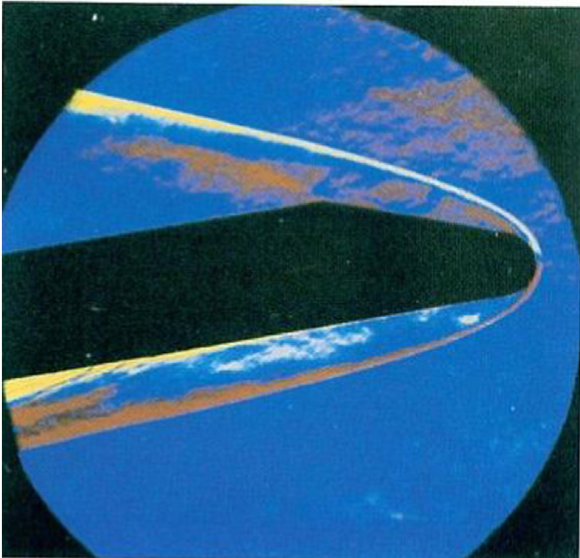

In [ ]:
# att module
model._att = True
xyz_volume = torch.tensor([0.4,0.3,-0.1,0,0,0]).unsqueeze(-1).unsqueeze(0)
with torch.no_grad():
    pred = model(xyzn_surf_source.to(device), xyz_volume.to(device)).squeeze(0)
pred = np.array(pred.to('cpu'))

In [ ]:
att_num = len(model.att_cache)//2
vpt_num = model.att_cache[1][0,:, :, :].shape[1]
spt_num = model.att_cache[0][0,:, :, :].shape[2]
att_tensor = torch.zeros(att_num, vpt_num, spt_num)
for att in range(att_num):
    # 这个计算用for循环验证过，输出形状[h,vpt,spt]
    att_tensor[att,:] = (model.att_cache[att*2+1][0,:, :, :]@model.att_cache[att*2][0,:,:,:]).sum(0)
    print(model.att_cache[att*2][0,:,:,:].shape)
    print(model.att_cache[att*2+1][0,:, :, :].shape)
print(f'completed, {att_tensor.shape}')
print(model.att_cache[0].shape, model.att_cache[1].shape, len(model.att_cache))
print(model.att_cache[1][0,0,0,:].sum(), model.att_cache[1][0,0,0,:].shape)
print(model.att_cache[0][0,0,0,:].sum(), model.att_cache[0][0,0,0,:].shape)
print(model.xyzn_surf_source.shape)



In [ ]:
import plotly.graph_objects as go
import numpy as np
import random

vpt_idx = random.randint(0, vpt_num-1)
att_idx = 0
# 生成1024个随机的XYZ坐标点
x = model.xyzn_surf_source[0,0,:]
y = -model.xyzn_surf_source[0,1,:]
z = model.xyzn_surf_source[0,2,:]

# 颜色的映射
if att_idx>=0:
    colors = att_tensor[att_idx,vpt_idx,:]
else:
    colors = att_tensor[:,vpt_idx,:].sum(0)

# 创建一个红色的大点在原点
red_point = go.Scatter3d(
    x=[xyz_volume[0,0,vpt_idx]],
    y=[-xyz_volume[0,1,vpt_idx]],
    z=[xyz_volume[0,2,vpt_idx]],
    mode='markers+text',
    text=f"({1:.2f}, {2:.2f}, {3:.2f})",  # 格式化坐标值并作为文本显示
    textposition='top center',# other options: top left, top right, middle center, middle left, middle right, bottom left, bottom center, bottom right
    marker=dict(
        color='red',
        size=4,  # 可以调整点的大小
        opacity=0.8
    ),
    name='Query point'
)

# 创建散点图
fig = go.Figure()

# 添加随机点
fig.add_trace(go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        color=colors,
        colorscale='Turbo',  # 可以选择不同的颜色映射
        size=5,  # 可以调整点的大小
        opacity=1
    ),
    showlegend=False
))

# 添加红色大点
fig.add_trace(red_point)

# 更新布局
fig.update_layout(
    width=500,
    height=400,
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        camera={
        "projection": {
            "type": "orthographic"
            }
        },
        aspectmode='data',
    )
)
# front x=-0.8, y=-1, z=0.5
# reward x=0.7, y=-1, z=0.5
fig.update_layout(scene_camera=dict(eye=dict(x=0.7, y=-1, z=0.5)))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))# tight layout
fig.update_layout(template = "ggplot2")# 较好 simple_white, seaborn, ggplot2, plotly_white, plotly_dark
fig.update_layout(legend=dict(x=0.75, y=0.8))
fig.show()

In [ ]:
import plotly.io as pio

# 列出所有可用的样式
print(pio.templates)

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import r2_score
from plotly.subplots import make_subplots
colorbar_title = ['<i>C<sub>p</sub></i>', 'Rho', 'Mach']

x = torch.tensor([0],dtype=torch.float32)
y = torch.linspace(-1, 1, 300)
z = torch.linspace(-1, 1, 300)
grid_x, grid_y, grid_z = torch.meshgrid(x, y, z)

xyz_volume = torch.concat([grid_x.reshape(1,-1), grid_y.reshape(1,-1), grid_z.reshape(1,-1)], dim=0)
xyz_volume = xyz_volume.unsqueeze(0)

xyz_volume = torch.concat((xyz_volume, torch.zeros((1,3,xyz_volume.shape[2]))), dim=1)# 3d to 6d
##
model.eval()
# Pred

with torch.no_grad():
    pred = model(xyzn_surf_source.to(device), xyz_volume.to(device)).squeeze(0)
pred = np.array(pred.to('cpu'))
# pred[pred>0.2] = 0.2


tmp = pred # pred_1d- gts_1d
fig = make_subplots(rows=1, cols=2,
                    specs=[[{'is_3d': True}, {'is_3d': True}]],
                    subplot_titles=[colorbar_title[0], colorbar_title[2]],
                    )
# 1
fig.add_trace(go.Scatter3d(
    x=xyz_volume[0, 0, :],
    y=xyz_volume[0, 1, :],
    z=xyz_volume[0, 2, :],
    mode='markers',
    marker=dict(
        size=2,
        color=tmp[0,:],
        colorscale='turbo',
        opacity=1,
        colorbar_x=0.4,
        colorbar=dict(title_text=colorbar_title[0], len=200, lenmode="pixels", thickness=10, thicknessmode="pixels")
    )
), 1, 1)


# surf
fig.add_trace(go.Mesh3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    # set the z-value as the intensity for the colorbar
    color='gray',
    opacity=1
), 1, 1)
# 2
fig.add_trace(go.Scatter3d(
    x=xyz_volume[0, 0, :],
    y=xyz_volume[0, 1, :],
    z=xyz_volume[0, 2, :],
    mode='markers',
    marker=dict(
        size=2,
        color=tmp[2,:],
        colorscale='turbo',
        opacity=1,
        colorbar=dict(title_text=colorbar_title[2], len=200, lenmode="pixels", thickness=10, thicknessmode="pixels")
    )
), 1, 2)

# surf
fig.add_trace(go.Mesh3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    # set the z-value as the intensity for the colorbar
    color='gray',
    opacity=1
), 1, 2)

fig.update_layout(scene=dict(aspectmode='data'))
# camera
# camera = dict(
#     eye=dict(x=0, y=-1.6, z=0)
# )
# camera2 =dict(
#     eye=dict(x=0, y=1.6, z=0)
# )
# fig.update_layout(scene1_camera=camera, scene2_camera=camera2)
fig.update_layout(scene1={
    "camera": {
        "projection": {
            "type": "orthographic"
        }
    },
    "xaxis": {"showticklabels": False},
    "yaxis": {"showticklabels": False},
    "zaxis": {"showticklabels": False}
},
scene2={
    "camera": {
        "projection": {
            "type": "orthographic"
        }
    },
    "xaxis": {"showticklabels": False},
    "yaxis": {"showticklabels": False},
    "zaxis": {"showticklabels": False}
},
)

fig.update_layout(scene_camera_eye=dict(x=0, y=1.6, z=0))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0.2))# tight layout
fig.update_layout(width=900, height=300)
fig.show()